SVC is the classification version of Support Vector Machines (SVMs).
It tries to find the best decision boundary (hyperplane) that separates different classes in the dataset.

Imagine data points belonging to two classes (say Pass/Fail).
SVC finds a line (in 2D) or hyperplane (in higher dimensions) that separates the two classes with the maximum margin.
The margin = distance between the hyperplane and the nearest data points from each class (called support vectors).
Both marginal planes are at equal distance from Hyperplane.

hard marginal plane : no errors
soft marginal plane : error present

y = mx + c
y = w1x1 + w2x2 +....+ wnxn + b
y = wᵗx + b

Aim is to keep maximum distence between two support vectors.
Margin(The distance from hyperplane to closest point) = 2 / ||w||   ,where ||w|| is magnitude of w
means we need to maximise the value of 2 / ||w|| or minimise the value of ||w|| / 2

Yi = +1 when wᵗx + b >= 1 and Yi = -1 when wᵗx + b <= -1
means Y * (wᵗx + b) >= 1  (Condition for correct classification)
 
                                  n
Cost Function : (||w|| / 2) + Ci  ∑ εi
                                 i=1
    where C is how many points we can avoid missclassification 
          ε is summation of the distance of missclassification points from marginal plane

Limitations :
Computationally expensive for large datasets.
Choosing right kernel and parameters is tricky.
Doesn’t perform well when classes overlap heavily.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('student_exam_scores.csv')

In [3]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [5]:
classifier = SVC(probability=True)

In [27]:
parameters = [
    {"kernel":["linear"],"C":[0.1, 1, 10, 100]},
    {"kernel":["poly"],"C": [0.1, 1, 10, 20], "degree": [2, 3, 4]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1, 1]},
    {"kernel": ["sigmoid"], "C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1, 1]},
    ]

In [28]:
gcv = GridSearchCV(classifier,parameters,cv=5,scoring="accuracy")

In [29]:
gcv.fit(x_train,y_train)

,estimator,SVC(probability=True)
,param_grid,"[{'C': [0.1, 1, ...], 'kernel': ['linear']}, {'C': [0.1, 1, ...], 'degree': [2, 3, ...], 'kernel': ['poly']}, ...]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [31]:
gcv.best_params_

{'C': 10, 'degree': 3, 'kernel': 'poly'}

In [32]:
print(gcv.best_score_)

0.9766666666666666


In [15]:
y_pred = gcv.predict(x_test)

In [18]:
from sklearn.metrics import accuracy_score,precision_score,log_loss,classification_report,confusion_matrix

In [16]:
print(accuracy_score(y_test,y_pred))

1.0


In [17]:
precision_score(y_test,y_pred)

1.0

In [19]:
log_loss(y_test,gcv.predict_proba(x_test))

0.03991010871236906

In [20]:
print(confusion_matrix(y_test, y_pred))

[[77  0]
 [ 0 23]]


d:\jbook\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


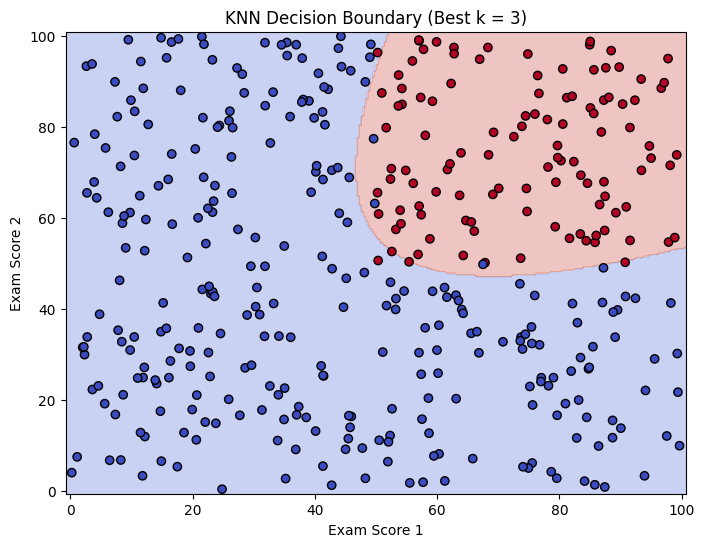

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Get best model from GridSearchCV
best_classifier = gcv.best_estimator_

# Create a mesh grid
x_min, x_max = x["Exam Score1"].min() - 1, x["Exam Score1"].max() + 1
y_min, y_max = x["Exam Score2"].min() - 1, x["Exam Score2"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Predict for each point in the grid
Z = best_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(x["Exam Score1"], x["Exam Score2"], c=y, cmap=plt.cm.coolwarm, edgecolors="k")
plt.xlabel("Exam Score 1")
plt.ylabel("Exam Score 2")
plt.title(f"KNN Decision Boundary (Best k = {gcv.best_params_['degree']})")
plt.show()
